In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

do_models = [
    "Qwen/Qwen3-4B",
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.1-8B-Instruct"
]
model_ablations = ["cadgn", "adgn", "gcn", "gat", "dec"]
mmd_vals = [0, 1]


bp = Path("./ablate_results/samples")
s1_p = bp / "stage1"


In [2]:
s1_df = pl.scan_parquet(s1_p / "stage1_derived_metrics.parquet")
s2_df = pl.scan_parquet(bp / "s2_BaselineSampleResults.parquet").rename({"model":"llm"})





In [3]:
## Make visual diagrams of correlation (spearman's r, as pearson's implies linear, which might not be true)
import matplotlib.lines as mlines
from scipy.stats import spearmanr
from sklearn.metrics import f1_score


# 1. Aggregate data

s1_agg_pd = (
    s1_df
    .group_by(["ablation", "mmd_val", "llm"])
    .agg([
        pl.col("auprc").mean().alias("s1_auprc"),
        pl.col("cosine_sim_mean").mean().alias("s1_cosine"),
    ])
    .collect()
    .to_pandas()
)

# Load s2_df as pandas for groupby + sklearn
s2_pd = s2_df.collect().to_pandas()
print(s2_pd.columns)

def compute_group_metrics(grp: pd.DataFrame) -> pd.Series:
    # yn_f1 : binary, exclude abstains
    yn_mask = grp["prediction"] != "abstain"
    if yn_mask.sum() > 0:
        yn_true = (grp.loc[yn_mask, "label"] == "yes").astype(int)
        yn_pred = (grp.loc[yn_mask, "prediction"] == "yes").astype(int)
        yn_f1 = f1_score(yn_true, yn_pred, zero_division=0.0)
    else:
        yn_f1 = 0.0

    # gate_f1_macro : multiclass
    gate_f1 = f1_score(
        grp["rung"],
        grp["gate_pred"],
        average="macro",
        zero_division=0.0,
    )

    return pd.Series({
        "s2_yn_f1":      yn_f1,
        "s2_gate_f1":    gate_f1,
        "s2_yn_acc":     grp["yn_correct"].mean(),
        "s2_gate_acc":   grp["gate_correct"].mean(),
        "s2_abstain_rate": (grp["prediction"] == "abstain").mean(),
        "n_samples":     len(grp),
    })

s2_agg = (
    s2_pd
    .groupby(["ablation", "mmd_val", "llm"])
    .apply(compute_group_metrics)
    .reset_index()
)

combined = s1_agg_pd.merge(s2_agg, on=["ablation", "mmd_val", "llm"], how="inner")

print(f"Combined shape: {combined.shape}")
print(combined.head())
print(combined.columns)


Index(['sample_id', 'rung', 'label', 'prediction', 'yn_correct', 'confidence',
       'yn_coverage', 'gate_pred', 'gate_correct', 'ablation', 'llm',
       'mmd_val'],
      dtype='str')
Combined shape: (40, 11)
  ablation  mmd_val                               llm  s1_auprc  s1_cosine  \
0      dec        0  meta-llama/Llama-3.2-3B-Instruct       1.0   0.988739   
1    cadgn        1  meta-llama/Llama-3.1-8B-Instruct       1.0   0.988016   
2      dec        1  meta-llama/Llama-3.2-3B-Instruct       1.0   0.988190   
3      gcn        1  meta-llama/Llama-3.1-8B-Instruct       1.0   0.944151   
4    cadgn        1  meta-llama/Llama-3.2-3B-Instruct       1.0   0.989010   

   s2_yn_f1  s2_gate_f1  s2_yn_acc  s2_gate_acc  s2_abstain_rate  n_samples  
0  0.392432    0.205191   0.492091     0.444640              0.0     1707.0  
1  0.660637    0.205191   0.494435     0.444640              0.0     1707.0  
2  0.661678    0.359181   0.496778     0.512595              0.0     1707.0  
3  0.66

In [4]:
# 2. Define Aesthetics
ablation_colours = {
    "cadgn": "#1f77b4",
    "adgn":  "#ff7f0e",
    "gat":   "#2ca02c",
    "gcn":   "#d62728",
    "dec":   "#9467bd",
}

mmd_markers = {0: "o", 1: "^"}
mmd_labels  = {0: "w_mmd=0", 1: "w_mmd=1"}

s1_metrics = [
    ("s1_auprc",  "Stage 1 AUPRC"),
    ("s1_cosine", "Stage 1 Cosine Similarity"),
]

llm_short = {m: m.split("/")[-1] for m in do_models}



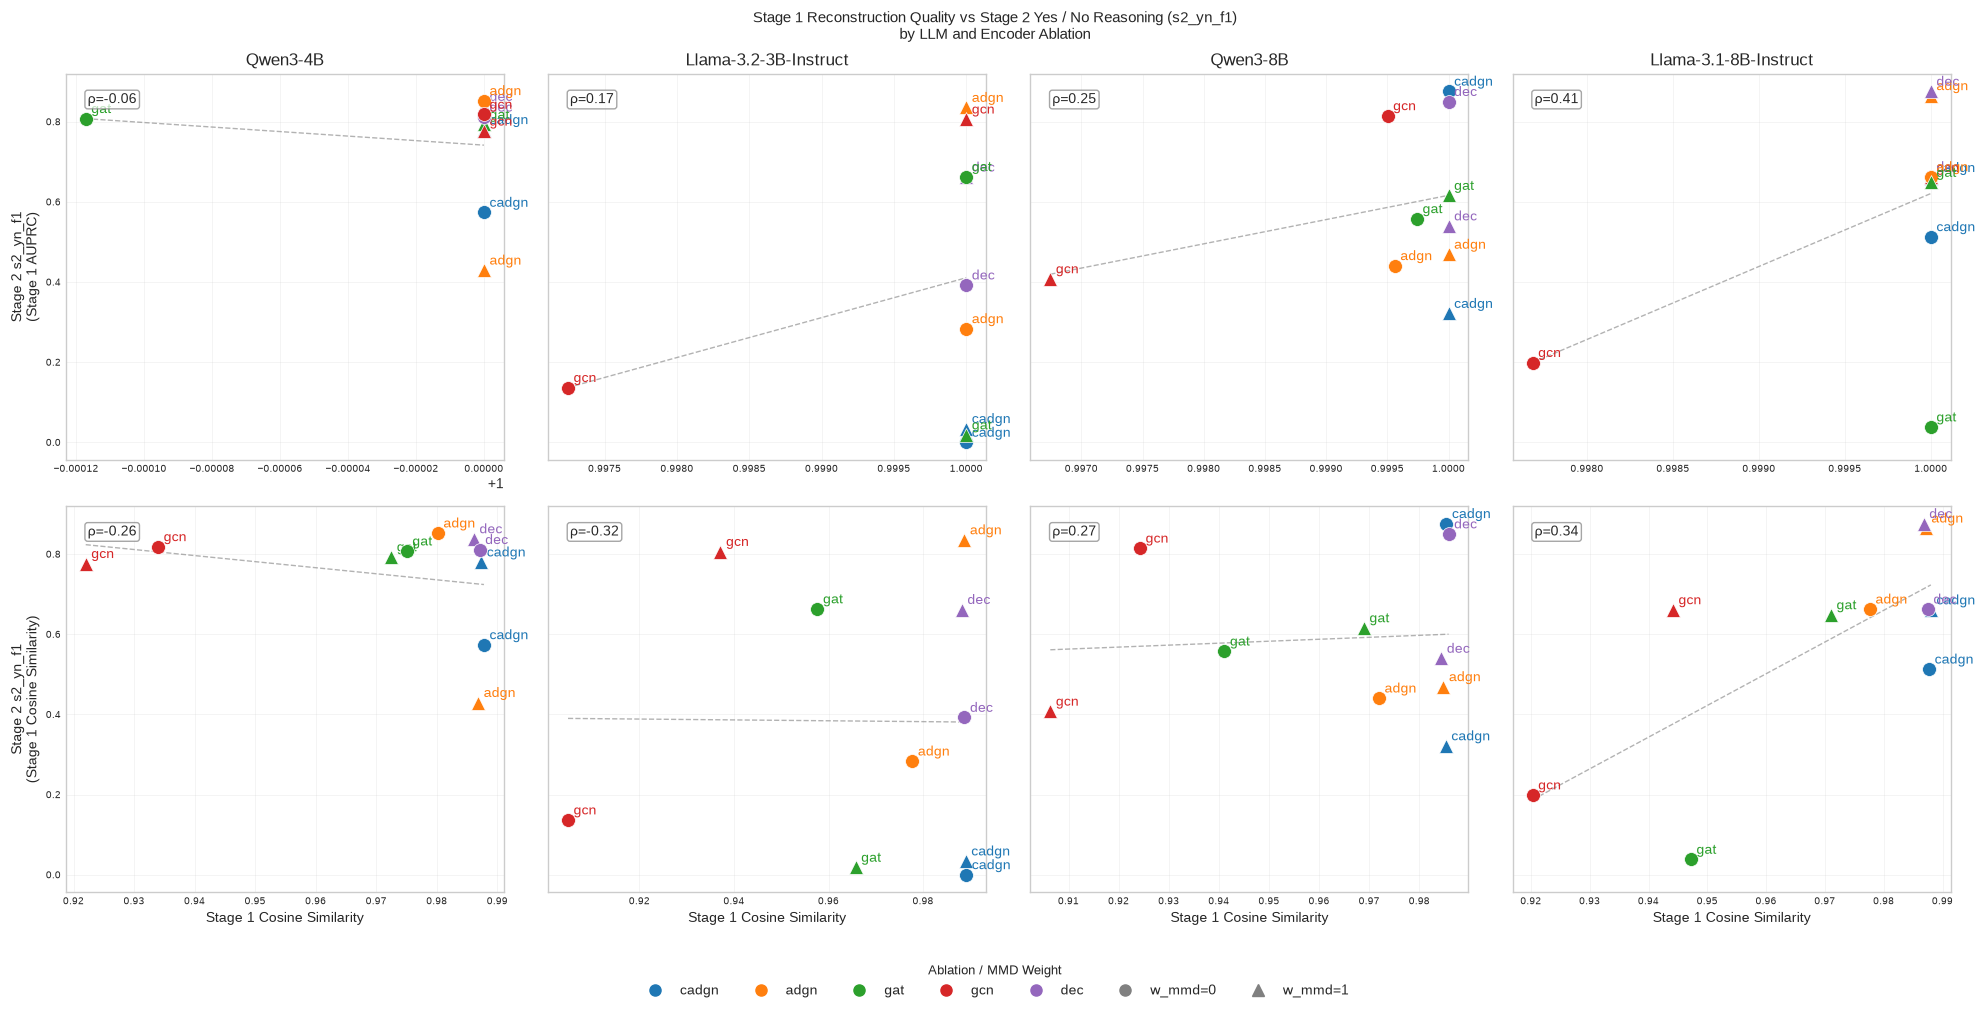

/tmp/ipykernel_397/260277543.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(subset[s1_col], subset[s2_t])
/tmp/ipykernel_397/260277543.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(subset[s1_col], subset[s2_t])
/tmp/ipykernel_397/260277543.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(subset[s1_col], subset[s2_t])
/tmp/ipykernel_397/260277543.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(subset[s1_col], subset[s2_t])


<Figure size 640x480 with 0 Axes>

{('s1_auprc', 'Qwen/Qwen3-4B'): (np.float64(-0.058025885318565944), np.float64(0.8734948923712951)), ('s1_auprc', 'meta-llama/Llama-3.2-3B-Instruct'): (np.float64(0.1740776559556978), np.float64(0.6305360755569765)), ('s1_auprc', 'Qwen/Qwen3-8B'): (np.float64(0.2526318345396), np.float64(0.48130830053792467)), ('s1_auprc', 'meta-llama/Llama-3.1-8B-Instruct'): (np.float64(0.40741767253225397), np.float64(0.24255674651066558)), ('s1_cosine', 'Qwen/Qwen3-4B'): (np.float64(-0.2606060606060606), np.float64(0.46708905438634024)), ('s1_cosine', 'meta-llama/Llama-3.2-3B-Instruct'): (np.float64(-0.32121212121212117), np.float64(0.36546831043867045)), ('s1_cosine', 'Qwen/Qwen3-8B'): (np.float64(0.2727272727272727), np.float64(0.4458383415427516)), ('s1_cosine', 'meta-llama/Llama-3.1-8B-Instruct'): (np.float64(0.3404271044608362), np.float64(0.33578226309853115))}


In [5]:
# 3. Plot
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 10),
    sharey="row",    # share y (s2_yn_f1) within each row
)

s2_target = ["s2_yn_f1", "s2_gate_f1"]
s2_map = {"s2_yn_f1": "Yes / No Reasoning", "s2_gate_f1":"PCH Classification"}

rhovals_targets = {}
for s2_idx, s2_t in enumerate(s2_target):
    rhovals_targets[s2_t] = {}
    for row_idx, (s1_col, s1_label) in enumerate(s1_metrics):
        for col_idx, llm in enumerate(do_models):
            ax = axes[row_idx, col_idx]

            subset = combined[combined["llm"] == llm]

            for _, point in subset.iterrows():
                abl     = point["ablation"]
                mmd_val = int(point["mmd_val"])

                ax.scatter(
                    point[s1_col],
                    point[s2_t],
                    color=ablation_colours.get(abl, "gray"),
                    marker=mmd_markers[mmd_val],
                    s=100,
                    zorder=3,
                    edgecolors="white",
                    linewidths=0.5,
                )

                # Label each point with ablation name
                ax.annotate(
                    abl,
                    xy=(point[s1_col], point[s2_t]),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=10,
                    color=ablation_colours.get(abl, "gray"),
                )

            # Spearman correlation for this panel
            if len(subset) >= 3:
                r, p = spearmanr(subset[s1_col], subset[s2_t])
                sig = "*" if p < 0.05 else ""
                ax.text(
                    0.05, 0.95,
                    f"ρ={r:.2f}{sig}",
                    transform=ax.transAxes,
                    fontsize=10,
                    verticalalignment="top",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7),
                )
                rhovals_targets[s2_t][(s1_col, llm)] = (r, p)

            # Regression line
            if len(subset) >= 3:
                m_fit, b_fit = np.polyfit(subset[s1_col], subset[s2_t], 1)
                x_range = np.linspace(subset[s1_col].min(), subset[s1_col].max(), 50)
                ax.plot(
                    x_range,
                    m_fit * x_range + b_fit,
                    color="gray",
                    linewidth=1.0,
                    linestyle="--",
                    alpha=0.6,
                    zorder=2,
                )

            # Titles and labels
            if row_idx == 0:
                ax.set_title(llm_short[llm], fontsize=12)
            if col_idx == 0:
                ax.set_ylabel(f"Stage 2 {s2_t}\n({s1_label})", fontsize=10)
            if row_idx == 1:
                ax.set_xlabel(s1_label, fontsize=10)

            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3, linewidth=0.5)

    # 4. Shared Legends
    # Ablation colour legend
    ablation_handles = [
        mlines.Line2D([], [], color=c, marker="o", linestyle="None",
                      markersize=8, label=abl)
        for abl, c in ablation_colours.items()
    ]

    # MMD marker legend
    mmd_handles = [
        mlines.Line2D([], [], color="gray", marker=mk, linestyle="None",
                      markersize=8, label=lbl)
        for mk, lbl in [(mmd_markers[0], mmd_labels[0]), (mmd_markers[1], mmd_labels[1])]
    ]

    fig.legend(
        handles=ablation_handles + mmd_handles,
        loc="lower center",
        ncol=len(ablation_colours) + 2,
        fontsize=10,
        title="Ablation / MMD Weight",
        title_fontsize=9,
        bbox_to_anchor=(0.5, -0.02),
    )

    fig.suptitle(
        f"Stage 1 Reconstruction Quality vs Stage 2 {s2_map[s2_t]} ({s2_t})\n"
        "by LLM and Encoder Ablation",
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(
        f"./ablate_results/figures/s1_{s2_t}_spearman_correlation.png",
        dpi=600, bbox_inches="tight"
    )
    plt.show()

print(rhovals_targets["s2_yn_f1"])

In [6]:
pairs = [
    ("s1_auprc",  "s2_yn_f1"),
    ("s1_auprc",  "s2_gate_f1"),
    ("s1_cosine", "s2_yn_f1"),
    ("s1_cosine", "s2_gate_f1"),
]

for x, y in pairs:
    r, p = spearmanr(combined[x], combined[y])
    print(f"{x} vs {y}: ρ={r:.3f}, p={p:.4f}")

s1_auprc vs s2_yn_f1: ρ=0.209, p=0.1954
s1_auprc vs s2_gate_f1: ρ=0.130, p=0.4231
s1_cosine vs s2_yn_f1: ρ=0.060, p=0.7120
s1_cosine vs s2_gate_f1: ρ=0.048, p=0.7665


In [7]:
## Partial Correlation (Control for LLM capacity)
ord_models = [
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen3-4B",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.1-8B-Instruct"
]

from pingouin import partial_corr

llm_order = {m: i for i, m in enumerate(ord_models)}
combined["llm_idx"] = combined["llm"].map(llm_order)

result = partial_corr(
    data=combined,
    x="s1_auprc",
    y="s2_yn_f1",
    covar="llm_idx",
    method="spearman"
)

print(result)


           n        r         CI95     p_val
spearman  40  0.22366  [-0.1, 0.5]  0.171086


In [8]:
print(combined[["ablation", "mmd_val", "llm", "s2_gate_f1"]].to_string())

print(combined[["ablation", "mmd_val", "llm", "s2_yn_f1"]]
      .sort_values("s2_yn_f1", ascending=False)
      .to_string())

print(f"s1_cosine range: {combined['s1_cosine'].min():.4f} – {combined['s1_cosine'].max():.4f}")
print(f"s2_yn_f1 range:  {combined['s2_yn_f1'].min():.4f} – {combined['s2_yn_f1'].max():.4f}")

   ablation  mmd_val                               llm  s2_gate_f1
0       dec        0  meta-llama/Llama-3.2-3B-Instruct    0.205191
1     cadgn        1  meta-llama/Llama-3.1-8B-Instruct    0.205191
2       dec        1  meta-llama/Llama-3.2-3B-Instruct    0.359181
3       gcn        1  meta-llama/Llama-3.1-8B-Instruct    0.205191
4     cadgn        1  meta-llama/Llama-3.2-3B-Instruct    0.205191
5       dec        1                     Qwen/Qwen3-4B    0.205191
6     cadgn        0                     Qwen/Qwen3-8B    0.205191
7       gcn        0  meta-llama/Llama-3.2-3B-Instruct    0.205191
8       dec        0                     Qwen/Qwen3-8B    0.205191
9     cadgn        1                     Qwen/Qwen3-4B    0.205191
10    cadgn        1                     Qwen/Qwen3-8B    0.205191
11    cadgn        0                     Qwen/Qwen3-4B    0.205191
12      gat        1                     Qwen/Qwen3-4B    0.205191
13     adgn        0  meta-llama/Llama-3.2-3B-Instruct    0.20

In [9]:
## Determine why one CADGN MMD 0 Llama-3.2-3B model has yn_f1 of 0?
from sklearn.metrics import classification_report

def check_instance(abl="cadgn", mmd_val=0, llm="meta-llama/Llama-3.2-3B-Instruct"):
    suspect = s2_pd[
        (s2_pd["ablation"] == abl) &
        (s2_pd["mmd_val"] == mmd_val) &
        (s2_pd["llm"] == llm)
    ]
    print(f"\n\t===>Checking for {abl} MMD-{mmd_val} on {llm}<===\n")
    preds = suspect["prediction"].value_counts()
    truth = suspect['label'].value_counts()

    print(preds)
    print(f"Label distribution: {truth.to_dict()}")
    print(f"yn_correct mean: {suspect['yn_correct'].mean():.4f}")
    print(f"abstain_rate: {(suspect['prediction'] == 'abstain').mean():.4f}")

    if preds.array[0] != sum(truth.array):
        yn_mask = suspect["prediction"] != "abstain"
        print(classification_report(
            suspect.loc[yn_mask, "label"],
            suspect.loc[yn_mask, "prediction"]
        ))
    #print(preds.array[0], sum(truth.array))


check_instance()
check_instance(mmd_val=1)


	===>Checking for cadgn MMD-0 on meta-llama/Llama-3.2-3B-Instruct<===

prediction
no    1707
Name: count, dtype: int64
Label distribution: {'no': 861, 'yes': 846}
yn_correct mean: 0.5044
abstain_rate: 0.0000

	===>Checking for cadgn MMD-1 on meta-llama/Llama-3.2-3B-Instruct<===

prediction
no     1676
yes      31
Name: count, dtype: int64
Label distribution: {'no': 861, 'yes': 846}
yn_correct mean: 0.5038
abstain_rate: 0.0000
              precision    recall  f1-score   support

          no       0.50      0.98      0.67       861
         yes       0.48      0.02      0.03       846

    accuracy                           0.50      1707
   macro avg       0.49      0.50      0.35      1707
weighted avg       0.49      0.50      0.35      1707



In [10]:
## Mixed Effects Regression
import statsmodels.formula.api as smf
import statsmodels.api as sm

## TODO: sort out quickly but properly: mixed effect causes problems due to violation of i.i.d in this data.
# Get all samples from the source (only required rows)

# Merge sample-level Stage 1 and Stage 2 results
sample_combined = (
    s1_df
    .join(
        s2_df,
        on=["sample_id", "ablation", "mmd_val", "llm"]
    )
    .collect()
    .to_pandas()
)

"""# Mixed effects logistic regression
# yn_correct ~ s1_auprc + s1_cosine, with (ablation|llm) as random effect

model = smf.mixedlm(
    "yn_correct ~ auprc + cosine_sim_mean",
    data=sample_combined,
    groups=sample_combined["llm"],
    re_formula="~ablation"
)
result = model.fit()
print(result.summary())"""

# Pooled model (primary test)
model = smf.glm("yn_correct ~ auprc + cosine_sim_mean + ablation + llm + mmd_val",
                data=sample_combined, family=sm.families.Binomial())
result = model.fit()
print(result.summary())

# Stratified per (ablation, llm) group
results = []
for (ab, ll), sub in sample_combined.groupby(["ablation", "llm"]):
    m = smf.glm("yn_correct ~ auprc + cosine_sim_mean + mmd_val",
                data=sub, family=sm.families.Binomial())
    r = m.fit()
    results.append({
        "ablation": ab,
        "llm": ll,
        "n": len(sub),
        "auprc_coef": r.params["auprc"],
        "auprc_p": r.pvalues["auprc"],
        "cosine_coef": r.params["cosine_sim_mean"],
        "cosine_p": r.pvalues["cosine_sim_mean"]
    })

grid = pd.DataFrame(results)
print(grid)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             yn_correct   No. Observations:                68280
Model:                            GLM   Df Residuals:                    68269
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -43835.
Date:                Tue, 15 Sep 2026   Deviance:                       87671.
Time:                        20:32:41   Pearson chi2:                 6.83e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.03161
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [11]:
sample_combined[["auprc", "yn_correct"]].corr()

,auprc,yn_correct
auprc,1.000000,0.013077
yn_correct,0.013077,1.000000


In [12]:
model = smf.ols(
    "yn_correct ~ auprc + cosine_sim_mean + C(llm) + C(ablation)",
    data=sample_combined
).fit(cov_type="cluster", cov_kwds={"groups": sample_combined["llm"]})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             yn_correct   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     5.641
Date:                Tue, 15 Sep 2026   Prob (F-statistic):             0.0946
Time:                        20:32:42   Log-Likelihood:                -46028.
No. Observations:               68280   AIC:                         9.208e+04
Df Residuals:                   68270   BIC:                         9.217e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

/home/jerry/venvs/CausalADGN_venv/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [22]:
import re
def _compute_practical_effects(
    margeff_df: pd.DataFrame,
    data: pd.DataFrame
) -> pd.Series:
    """
    Adds a practical_effect column to a marginal effects DataFrame.

    - Continuous variables: dy/dx * (max − min) in the observed data.
    - Categorical variables: spread of dy/dx across all categories,
      including the implicit reference category (dy/dx = 0). The same
      spread value is assigned to every row in the group, so the reader
      can see the total categorical range on each row.
    """
    cat_pattern = re.compile(r"^C\((.+?)\)")
    dydx = margeff_df["dy/dx"]

    # --- Pass 1: collect categorical group values (include reference = 0) ---
    cat_groups: dict[str, list[float]] = {}
    for idx in margeff_df.index:
        m = cat_pattern.match(str(idx))
        if m:
            var = m.group(1)
            cat_groups.setdefault(var, [0.0]).append(float(dydx[idx]))

    cat_spreads = {
        var: max(vals) - min(vals)
        for var, vals in cat_groups.items()
    }

    # --- Pass 2: assign per-row practical effects ---
    practical: dict[str, float | None] = {}
    for idx in margeff_df.index:
        m = cat_pattern.match(str(idx))
        if m:
            practical[idx] = cat_spreads[m.group(1)]
        else:
            if idx in data.columns:
                obs_range = data[idx].max() - data[idx].min()
                practical[idx] = float(dydx[idx]) * obs_range
            else:
                practical[idx] = None  # shouldn't happen, but safe fallback

    return pd.Series(practical, name="practical_effect")



def make_model_results_excel(result, data: pd.DataFrame, path: Path):
    coef_df    = result.summary2().tables[1]
    margeff_df = result.get_margeff().summary_frame().copy()

    margeff_df.insert(1, "practical_effect",
                      _compute_practical_effects(margeff_df, data))

    model_stats = pd.Series({
        "n_obs":            result.nobs,
        "df_model":         result.df_model,
        "df_resid":         result.df_resid,
        "log_likelihood":   result.llf,
        "ll_null":          result.llnull,
        "pseudo_r2":        result.prsquared,
        "llr_pvalue":       result.llr_pvalue,
    })

    with pd.ExcelWriter(path) as writer:
        coef_df.to_excel(writer, sheet_name="Coefficients")
        margeff_df.to_excel(writer, sheet_name="Marginal Effects")
        model_stats.to_frame("value").to_excel(writer, sheet_name="Model Stats")

rq234_p = Path("./ablate_results/figures/s2_s1_comparisons/")
rq234_p.mkdir(parents=True, exist_ok=True)

In [23]:

models: dict[str, tuple] = {
    "Stage 1 only": ("yn_correct ~ auprc + cosine_sim_mean + C(ablation)", "reglogit_wo-llm-mmd.xlsx"),
    "`+ MMD": ("yn_correct ~ auprc + cosine_sim_mean + C(ablation) + C(mmd_val)", "reglogit_wo-llm_w-mmd.xlsx"),
    "`+ LLM": ("yn_correct ~ auprc + cosine_sim_mean + C(ablation) + C(llm)", "reglogit_wo-mmd_w-llm.xlsx"),
    "`+ LLM + MMD (full)": ("yn_correct ~ auprc + cosine_sim_mean + C(ablation) + C(mmd_val) + C(llm)", "reglogit_all.xlsx"),
}

rows = []
for label, (formula, fn) in models.items():
    model = smf.logit(
        formula,
        data=sample_combined
    ).fit(cov_type="HC3", disp=True)


    print(model.summary())

    # Convert Log-Odds to probability changes (interpretable)
    me = model.get_margeff()
    print(me.summary())
    me_frame = me.summary_frame()

    rows.append({
        "model":            label,
        "auprc_effect":     me_frame.loc["auprc", "dy/dx"],
        "cosine_effect":    me_frame.loc["cosine_sim_mean", "dy/dx"],
        "pseudo_r2":        model.prsquared,
        "aic":              model.aic,
    })

    make_model_results_excel(model, sample_combined, rq234_p / fn)

pd.DataFrame(rows).to_csv(rq234_p / "confounding_decomposition.csv", index=False)

Optimization terminated successfully.
         Current function value: 0.654781
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             yn_correct   No. Observations:                68280
Model:                          Logit   Df Residuals:                    68273
Method:                           MLE   Df Model:                            6
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                0.004977
Time:                        22:16:32   Log-Likelihood:                -44708.
converged:                       True   LL-Null:                       -44932.
Covariance Type:                  HC3   LLR p-value:                 1.881e-93
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.4538      1.082     -3.192      0.001      -5.574      -1.333

              auprc  cosine_sim_mean
count  68280.000000     68280.000000
mean       0.999759         0.968537
std        0.007653         0.052169
min        0.679167         0.433072
25%        1.000000         0.968526
50%        1.000000         0.989562
75%        1.000000         0.996498
max        1.000000         0.998896
AUPRC  IQR: 0.00000, IQR-scaled effect: 0.00000
Cosine IQR: 0.02797, IQR-scaled effect: 0.00503
